In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

data = pd.read_csv('car_price.csv')


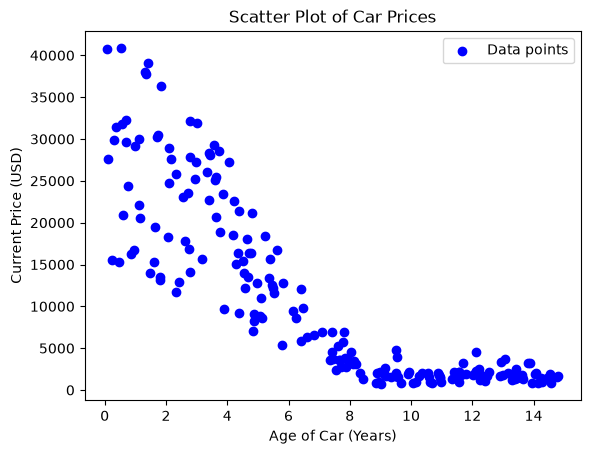

In [3]:

X=data[["Age_Years"]]
y=data["Current_Price_USD"]
plt.scatter(X, y, color='blue', label='Data points')
plt.xlabel('Age of Car (Years)')
plt.ylabel('Current Price (USD)')
plt.title('Scatter Plot of Car Prices')
plt.legend()
plt.show()

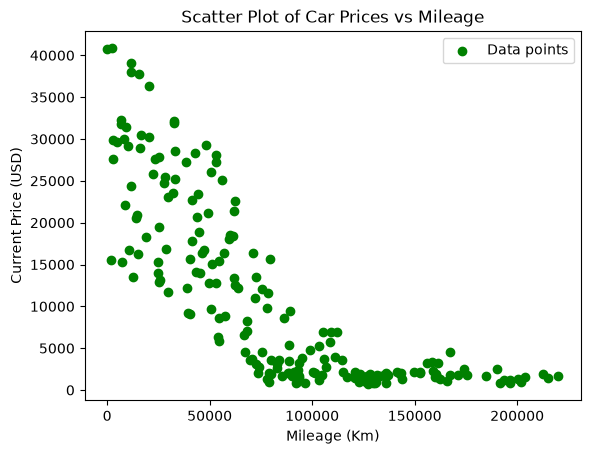

In [7]:
X = data[["Mileage_KM"]]
y = data["Current_Price_USD"]
plt.scatter(X, y, color='green', label='Data points')
plt.xlabel('Mileage (Km)')
plt.ylabel('Current Price (USD)')
plt.title('Scatter Plot of Car Prices vs Mileage')
plt.legend()
plt.show()

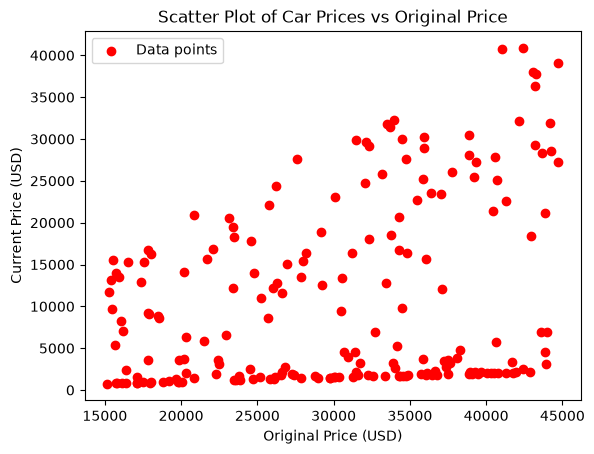

In [8]:
X = data[["Original_Price_USD"]]
y = data["Current_Price_USD"]
plt.scatter(X, y, color='red', label='Data points')
plt.xlabel('Original Price (USD)')
plt.ylabel('Current Price (USD)')
plt.title('Scatter Plot of Car Prices vs Original Price')
plt.legend()
plt.show()

In [9]:
corr = data.corr(numeric_only=True)

print(corr)

                    Age_Years  Mileage_KM  Original_Price_USD  \
Age_Years            1.000000    0.936015           -0.026881   
Mileage_KM           0.936015    1.000000           -0.055927   
Original_Price_USD  -0.026881   -0.055927            1.000000   
Current_Price_USD   -0.848156   -0.782307            0.326459   

                    Current_Price_USD  
Age_Years                   -0.848156  
Mileage_KM                  -0.782307  
Original_Price_USD           0.326459  
Current_Price_USD            1.000000  


In [7]:
X = data[["Age_Years", "Mileage_KM", "Original_Price_USD"]]
y = data["Current_Price_USD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head(10))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)


       Actual     Predicted
95    4510.33  10430.422463
15   16819.35  17098.175181
30    1942.22   9388.534907
158  29263.43  23538.885010
128  27588.00  24703.689692
115   3744.84   -523.088493
69    1721.25  -5148.870999
170    901.17    684.045908
174    856.78   2017.402308
45    2142.48  11010.824401
RMSE: 4634.6237981887625
Mean Absolute Error: 3839.068468381177
R-squared: 0.8292031870038223


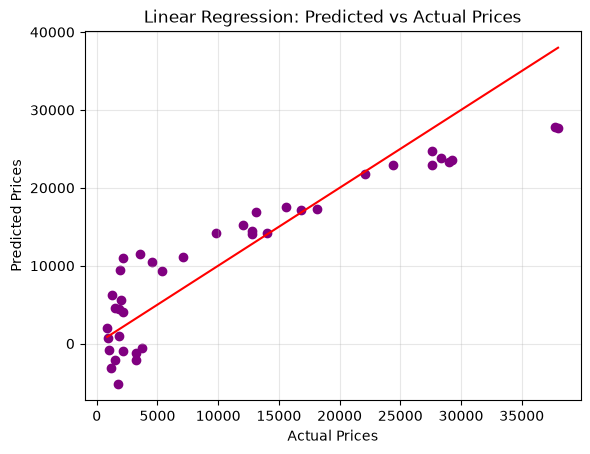

In [17]:
plt.scatter(y_test, y_pred, color='purple', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Prediction')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Linear Regression: Predicted vs Actual Prices')
plt.grid(alpha=0.3)
plt.show()

     Metric  Linear Regression  Polynomial Regression
0  R² Score           0.829203               0.916427
1       MAE        3839.068468            2734.592697
2      RMSE        4634.623798            3241.956995


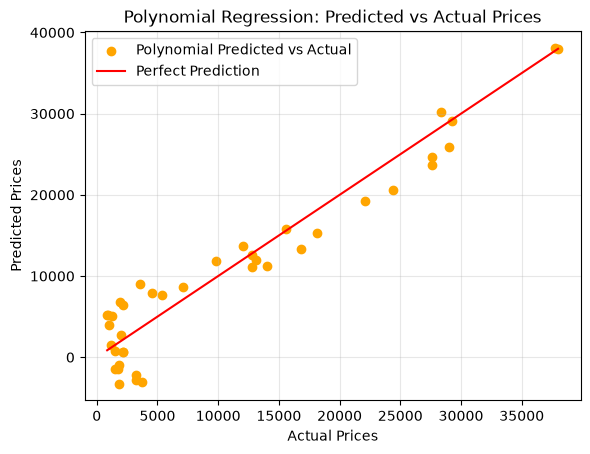

In [ ]:
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X_train)
poly_reg_model = LinearRegression()
poly_reg_model.fit(X_poly, y_train)
X_test_poly = poly_features.transform(X_test)
y_poly_pred = poly_reg_model.predict(X_test_poly)
poly_r2 = r2_score(y_test, y_poly_pred)
poly_mae = mean_absolute_error(y_test, y_poly_pred)
poly_rmse = np.sqrt(mean_squared_error(y_test, y_poly_pred))

results = pd.DataFrame({
    "Metric": ["R² Score", "MAE", "RMSE"],
    "Linear Regression": [
        r2,
        mae,
        rmse
    ],
    "Polynomial Regression": [
        poly_r2,
        poly_mae,
        poly_rmse
    ]
})

print(results)
plt.scatter(y_test, y_poly_pred, color='orange', label='Polynomial Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Prediction')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Polynomial Regression: Predicted vs Actual Prices')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [14]:
import joblib
joblib.dump(poly_reg_model, "models/polynomial_model.pkl")
joblib.dump(polynomial_features, "models/polynomial_features.pkl")

['models/polynomial_features.pkl']

In [15]:
loaded_model = joblib.load("models/polynomial_model.pkl")

loaded_transformer = joblib.load("models/polynomial_features.pkl")

In [21]:
new_car= pd.DataFrame({
    "Age_Years":[5],
    "Mileage_KM":[60000],
    "Original_Price_USD":[30000]
})
new_car_poly = loaded_transformer.transform(new_car)
prediction = loaded_model.predict(new_car_poly)
print(f"Predicted Current Price for the new car: ${prediction[0]:,.2f}")

Predicted Current Price for the new car: $12,956.42
